In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix1,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix1,kidney_data,sign,smooth,true_bound,smooth
import matplotlib.pyplot as plt
CUDA_LAUNCH_BLOCKING=1

def kidney_curve(x, y, h, k, a):
    """
    计算给定点 (x, y) 的肾形线隐式函数值。
    
    参数:
    x, y: 输入的坐标点。
    h, k: 肾形线中心的坐标 (用于平移)。
    a:    肾形线的尺寸参数。
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # 避免当 a=0 时出现问题
    if a == 0:
        a = 1e-9

    # 肾形线的隐式方程: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. 主高斯源 (模拟肿瘤)
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """肾形源项函数"""
    x = X[:, 0]
    y = X[:, 1]
    # 肾形源（平移+缩放）
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """改进后的复杂源项函数"""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # 肾形源（平移+缩放）
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss



cuda:0


In [2]:
import copy
np.random.seed(2)
torch.manual_seed(2)
torch.cuda.manual_seed_all(2) #固定随机种子
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101] #网格点索引
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=20
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.6,0.25])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=0
number=120
a=0.05
S_int_true,F_mea_b,F_mea_db_x1,F_mea_db_x2=kidney_data.boundary_data_circle(kk,120,points_b,kidney_source,0,1,0,1,center_true,1,a,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true_g,F_mea_b_g,F_mea_db_x1_g,F_mea_db_x2_g=kidney_data.boundary_data_rec(kk,120,points_b,Gauss_source,0,1,0,1,center_true,1,eps,mea,batch_number_rec_mea,device,cupy_device)
F=org_m.F(F_mea_b+F_mea_b_g,F_mea_db_x1+F_mea_db_x1_g,F_mea_db_x2+F_mea_db_x2_g)
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [5]:
M=4983
af="Tanh"   #先用tanh
R_m=20
cupy_device= 0
model_tanh = net_2D_fix2.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=0.18, r_max=0.22,b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af="Tanh",Shape="general",device=device).to(device)

In [4]:
model_tanh.load_state_dict(torch.load("./noise=5%/model_tanh.pth"))

<All keys matched successfully>

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


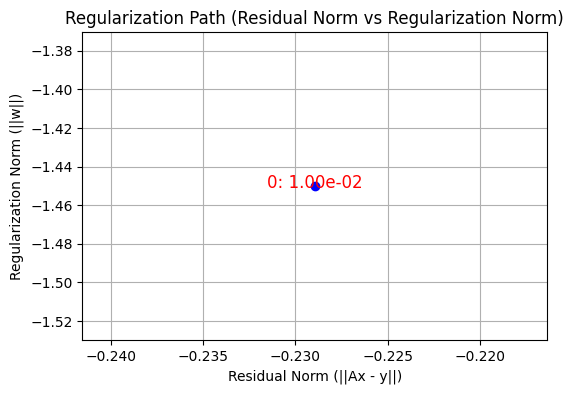

第 0 次迭代的train误差：
S_l_inf= 2.693274589405457 S_L_2= 0.2740366094050705 S_l_2= 0.8150128751898741
第 0 次迭代的泛化误差：


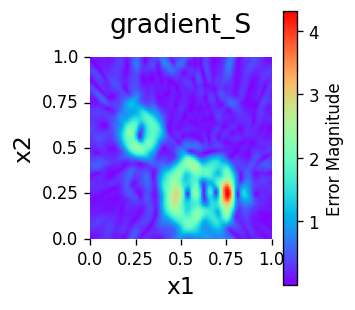

S_l_inf= 3.023444027948029 S_L_2= 0.27814615373890084 S_l_2= 0.8324625572401023


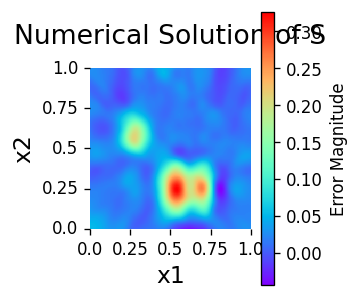

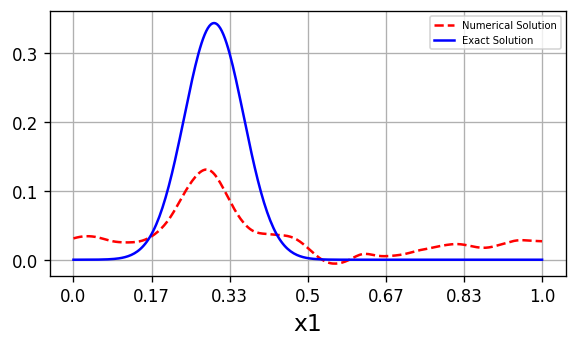

第 0 次自适应网格细分...
S_l_inf= 2.693274589405457 S_L_2= 0.2740366094050705 S_l_2= 0.8150128751898741
S_l_inf= 2.921402182721583 S_L_2= 0.2839172270610074 S_l_2= 0.8369930656269151
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


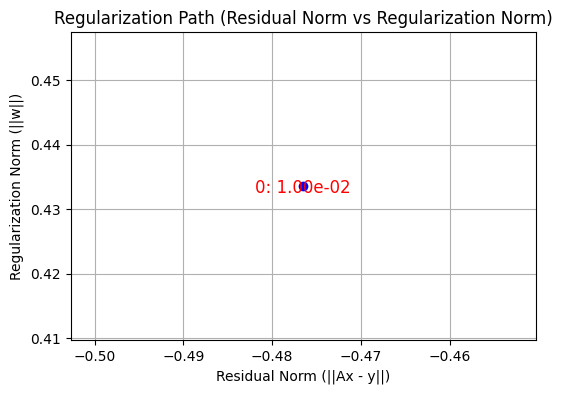

第 1 次迭代的train误差：
S_l_inf= 3.6915632033764365 S_L_2= 0.1890806117235161 S_l_2= 0.5574130266603083
第 1 次迭代的泛化误差：


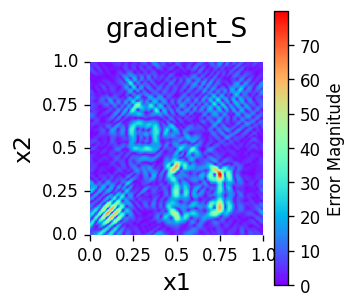

S_l_inf= 4.345703609788781 S_L_2= 0.20770255379907204 S_l_2= 0.6216321770287109


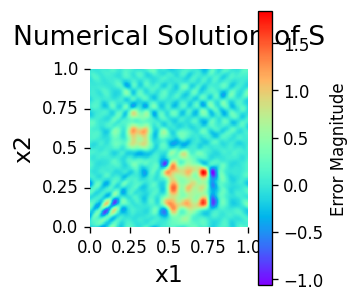

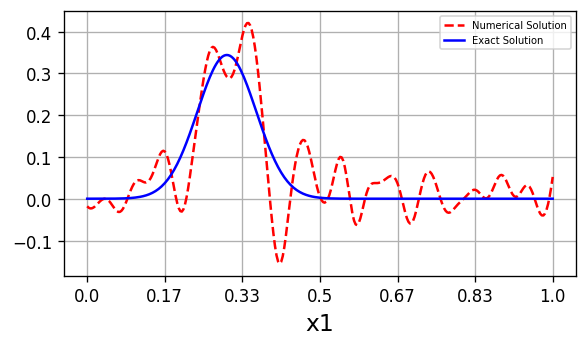

第 1 次自适应网格细分...
S_l_inf= 3.6915632033764365 S_L_2= 0.1890806117235161 S_l_2= 0.5574130266603083
S_l_inf= 3.251089198709736 S_L_2= 0.19498996758335038 S_l_2= 0.5830458852268485
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


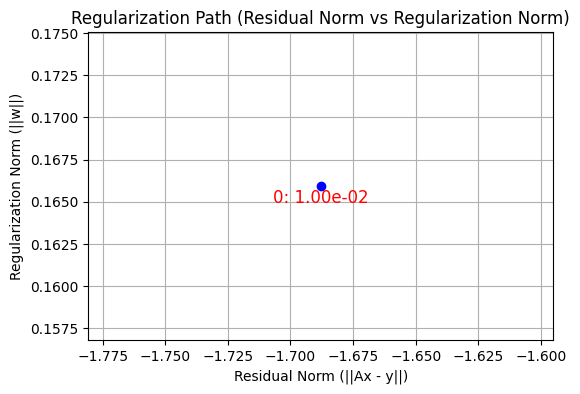

第 2 次迭代的train误差：
S_l_inf= 1.5428479395712817 S_L_2= 0.06169164682576686 S_l_2= 0.18338217853105201
第 2 次迭代的泛化误差：


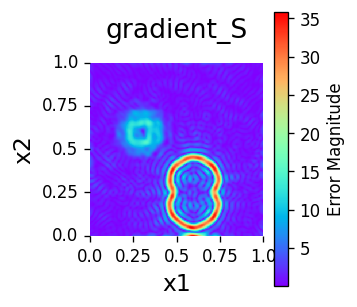

S_l_inf= 2.6590985415580977 S_L_2= 0.06262655694734781 S_l_2= 0.18743478220616028


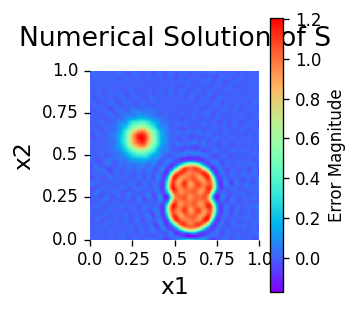

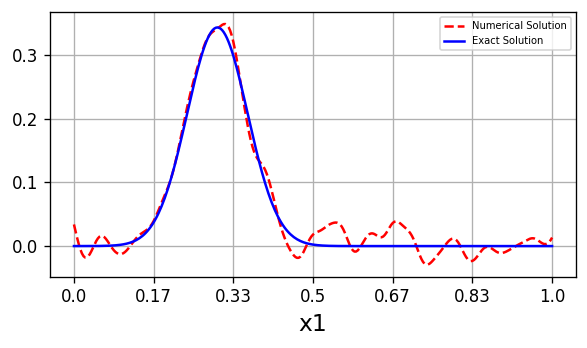

第 2 次自适应网格细分...
S_l_inf= 1.5428479395712817 S_L_2= 0.06169164682576686 S_l_2= 0.18338217853105201
S_l_inf= 1.7107622250853085 S_L_2= 0.062007175478729255 S_l_2= 0.1837858438326143
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


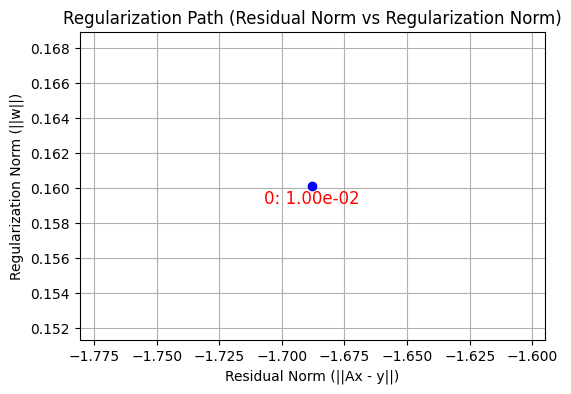

第 3 次迭代的train误差：
S_l_inf= 1.097296542151692 S_L_2= 0.08987580798576573 S_l_2= 0.1777888021393573
第 3 次迭代的泛化误差：


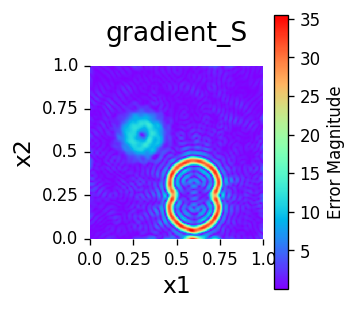

S_l_inf= 2.573787952400875 S_L_2= 0.0616797475427929 S_l_2= 0.18460107996890182


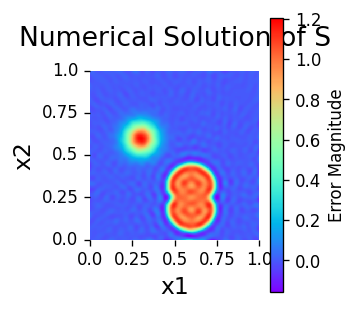

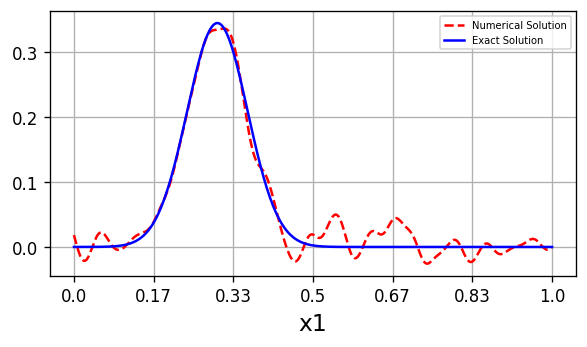

第 3 次自适应网格细分...
S_l_inf= 1.097296542151692 S_L_2= 0.08987580798576573 S_l_2= 0.1777888021393573
S_l_inf= 1.4488964581760557 S_L_2= 0.09121292625307599 S_l_2= 0.18067421843455084
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


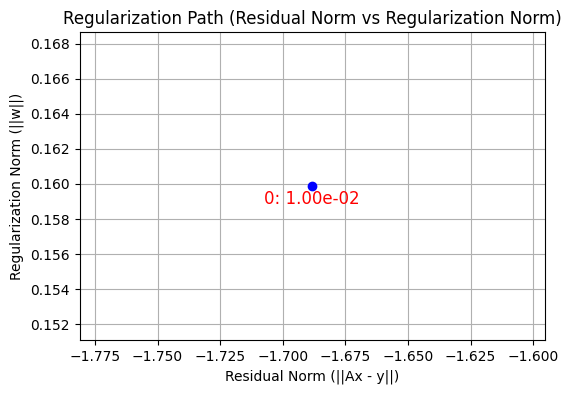

第 4 次迭代的train误差：
S_l_inf= 1.0897047404817874 S_L_2= 0.09028238589064184 S_l_2= 0.17739093237860457
第 4 次迭代的泛化误差：


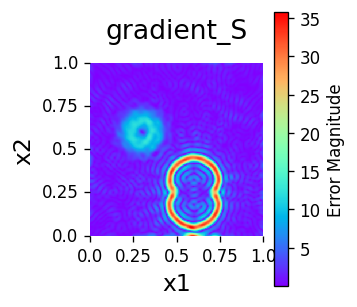

S_l_inf= 2.5752475634459433 S_L_2= 0.06167444500878992 S_l_2= 0.1845852100352118


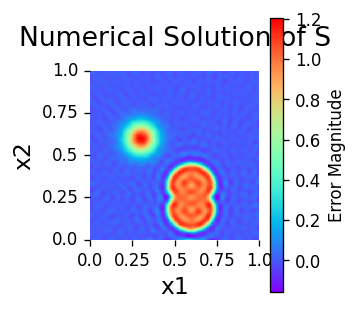

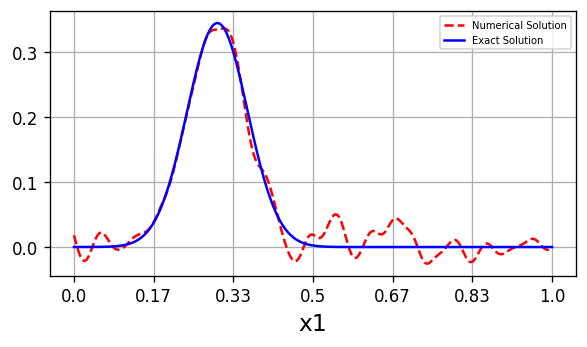

第 4 次自适应网格细分...
S_l_inf= 1.10382911217948 S_L_2= 0.09016441593035802 S_l_2= 0.17945541444520535
S_l_inf= 1.459082882165044 S_L_2= 0.09152442060712877 S_l_2= 0.18242920198171664
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


In [6]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
Shape=[]
# refine_threshold_S= [1e-2] * 5
# refine_threshold_grad=[1e-7] * 5
# refine_threshold_noise=[5e-3] * 5
refine_threshold_S= [1/100] * 5
refine_threshold_grad=[1/100000] * 5
refine_threshold_noise=[1/300] * 5
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix1.ada_int(iter_int,delta,cells,nx,model_tanh,M,af,Shape,[],kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,elegant_source,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)
